# Visualize fitted embedding

Loads `results/embedding.csv` (written by `fit_embedding.py`); falls back to PCA for higher dimensions (>>3).

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
em = pd.read_csv(repo / "results" / "embedding.csv") #specify which embedding to use
dims = [c for c in em.columns if c.startswith("dim_")]
print(f"{len(em)} words, {len(dims)} dimensions")
em.head()

17 words, 2 dimensions


,word,dim_0,dim_1
0,design pattern,0.038489,-0.924273
1,heuristic,0.603930,0.161925
2,requirement,-1.437306,-0.122539
3,implication,0.414857,1.075636
4,principle,-0.574186,-0.327545


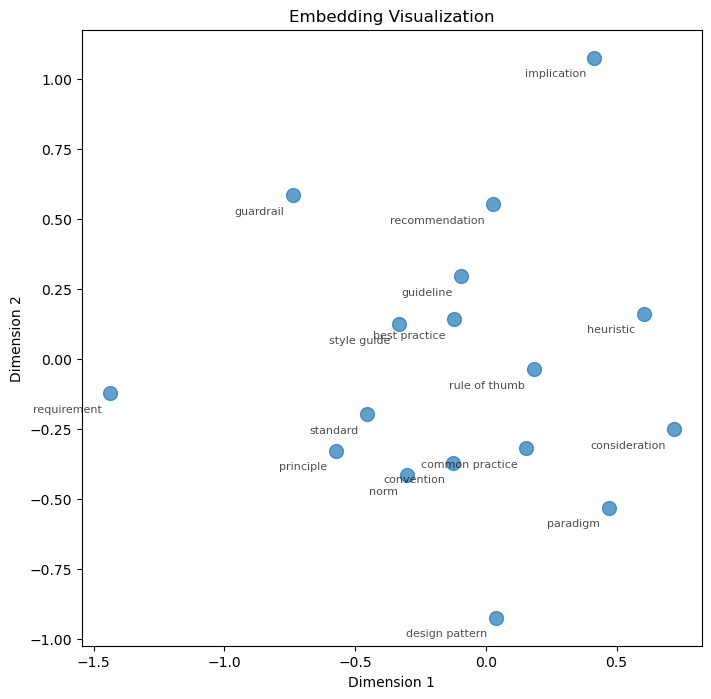

' fig, ax = plt.subplots(figsize=(8, 8))\nax.scatter(em[\'dim_0\'], em[\'dim_2\'], s=100, alpha=0.7) \nax.set_title("Embedding Visualization")\n### annotate each point with its word\nfor i, word in enumerate(em[\'word\']):\n    ax.annotate(\n        word,\n        (em[\'dim_0\'][i], em[\'dim_2\'][i]),\n        xytext=(-6, -8),\n        textcoords=\'offset points\',\n        ha=\'right\',\n        va=\'top\',\n        fontsize=8,\n        alpha=0.7\n    )\nax.set_xlabel("Dimension 1")\nax.set_ylabel("Dimension 3")\nplt.show() '

In [3]:
### display dim 1 and dim 2
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(em['dim_0'], em['dim_1'], s=100, alpha=0.7)
ax.set_title("Embedding Visualization")
### annotate each point with its word
for i, word in enumerate(em['word']):
    ax.annotate(
        word,
        (em['dim_0'][i], em['dim_1'][i]),
        xytext=(-6, -8),
        textcoords='offset points',
        ha='right',
        va='top',
        fontsize=8,
        alpha=0.7
    )
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
plt.show()

### display dim 1 and dim 3
""" fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(em['dim_0'], em['dim_2'], s=100, alpha=0.7) 
ax.set_title("Embedding Visualization")
### annotate each point with its word
for i, word in enumerate(em['word']):
    ax.annotate(
        word,
        (em['dim_0'][i], em['dim_2'][i]),
        xytext=(-6, -8),
        textcoords='offset points',
        ha='right',
        va='top',
        fontsize=8,
        alpha=0.7
    )
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 3")
plt.show() """

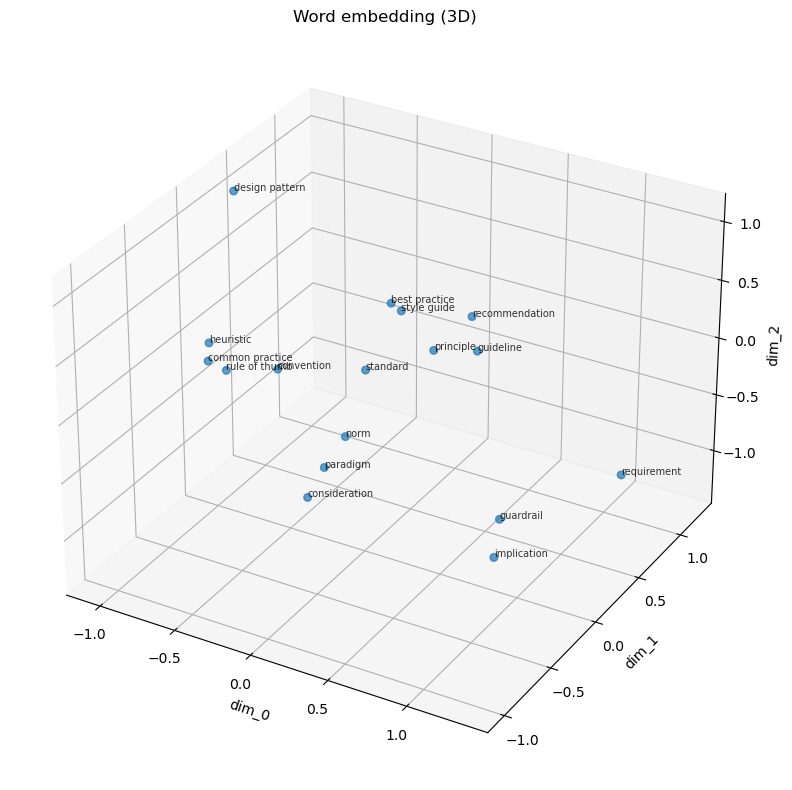

In [5]:
# 3D view (only if the embedding has >= 3 dims)
if len(dims) >= 3:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    xs, ys, zs = em[dims[0]], em[dims[1]], em[dims[2]]
    ax.scatter(xs, ys, zs, s=30, alpha=0.7)
    for x, y, z, w in zip(xs, ys, zs, em["word"]):
        ax.text(x, y, z, w, fontsize=7, alpha=0.8)
    ax.set_xlabel(dims[0])
    ax.set_ylabel(dims[1])
    ax.set_zlabel(dims[2])
    ax.set_title("Word embedding (3D)")
    plt.tight_layout()
    plt.show()
else:
    print("Embedding has fewer than 3 dimensions — skipping 3D plot.")